In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from functools import partial
from tqdm import tqdm

import json

import os

In [2]:
ALL_RESULTS_PATHS = glob.glob("results_with_error_hint/*/*/*.json")
ALL_RESULTS_PATHS[:5], len(ALL_RESULTS_PATHS)

(['results_with_error_hint\\anthropic_claude_haiku_4_5\\ExtraSteps\\1002.json',
  'results_with_error_hint\\anthropic_claude_haiku_4_5\\ExtraSteps\\101.json',
  'results_with_error_hint\\anthropic_claude_haiku_4_5\\ExtraSteps\\1022.json',
  'results_with_error_hint\\anthropic_claude_haiku_4_5\\ExtraSteps\\1025.json',
  'results_with_error_hint\\anthropic_claude_haiku_4_5\\ExtraSteps\\1034.json'],
 6500)

In [3]:
RESULTS_DICT = {} # model -> perturbation -> list of results

In [4]:
for result_file in tqdm(ALL_RESULTS_PATHS):
    parts = result_file.split("\\")
    model = parts[1]
    perturbation = parts[2]
    if perturbation == "UnitConv":
        continue
    q_id = int(parts[3].split(".")[0])
    
    if model not in RESULTS_DICT:
        RESULTS_DICT[model] = {}
    if perturbation not in RESULTS_DICT[model]:
        RESULTS_DICT[model][perturbation] = {}
    
    with open(result_file, "r") as f:
        result_data = json.load(f)
        RESULTS_DICT[model][perturbation][q_id] = result_data

100%|██████████| 6500/6500 [00:55<00:00, 116.93it/s]


In [5]:
RESULTS_DICT.keys()

dict_keys(['anthropic_claude_haiku_4_5', 'anthropic_claude_sonnet_4_5', 'deepseek_deepseek_v3_2', 'google_gemini_3_flash_preview', 'google_gemma_3_4b_it', 'meta_llama_llama_3_1_8b_instruct', 'meta_llama_llama_4_scout', 'mistralai_ministral_3b', 'mistralai_ministral_8b_2512', 'mistralai_mistral_large_2512', 'openai_gpt_4o_mini', 'openai_gpt_5_2', 'qwen_qwen3_235b_a22b_2507'])

In [6]:
# model to size map
import math
MODEL_SIZE_MAP = {
    # 'openai_gpt_5_2': 1500,
    # 'anthropic_claude_sonnet_4_5': 1500,
    # 'anthropic_claude_haiku_4_5': 1000,
    # # 'google_gemini_3_pro_preview': 2000,
    # 'openai_gpt_4o_mini': 1000,
    # 'google_gemini_3_flash_preview': 1000,

    'openai_gpt_5_2': 2000,
    'anthropic_claude_sonnet_4_5': 1200,
    'anthropic_claude_haiku_4_5': 500,
    # 'google_gemini_3_pro_preview': 2000,
    'openai_gpt_4o_mini': 8,
    'google_gemini_3_flash_preview': 1200,


    'deepseek_deepseek_v3_2': 685,
    'mistralai_mistral_large_2512': 675,
    'qwen_qwen3_235b_a22b_2507': 235,
    'meta_llama_llama_3_1_8b_instruct': 8,
    'meta_llama_llama_4_scout': 109,
    'mistralai_ministral_8b_2512': 8,
    'mistralai_ministral_3b': 3,
    'google_gemma_3_4b_it': 4,
}

In [7]:
# RESULTS_DICT['azure_gpt_4o_mini'].keys()

In [8]:
for key in RESULTS_DICT['openai_gpt_5_2'].keys():
    print(key, len(RESULTS_DICT['openai_gpt_5_2'][key]))

ExtraSteps 100
MathError 100
SkippedSteps 100
Sycophancy 100
UnitConvFinal 100


In [9]:
for key in RESULTS_DICT['openai_gpt_5_2'].keys():
    print(key)
    q_id_random = list(RESULTS_DICT['openai_gpt_5_2'][key].keys())[0]
    print("Question ID: ", q_id_random)
    print("Correct answer: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['answer'])
    print("Model answer clean question: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['answer_solution_clean'])
    print("Model answer perturbed question: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['answer_solution_perturbed'])

ExtraSteps
Question ID:  1002
Correct answer:  113.0
Model answer clean question:  113
Model answer perturbed question:  113
MathError
Question ID:  1002
Correct answer:  33.0
Model answer clean question:  113
Model answer perturbed question:  113
SkippedSteps
Question ID:  1002
Correct answer:  nan
Model answer clean question:  113
Model answer perturbed question:  113
Sycophancy
Question ID:  1002
Correct answer:  113.0
Model answer clean question:  113
Model answer perturbed question:  113
UnitConvFinal
Question ID:  1021
Correct answer:  30.0
Model answer clean question:  30
Model answer perturbed question:  30


In [10]:
RESULTS_DICT['openai_gpt_5_2'][key][q_id_random].keys()

dict_keys(['id', 'question', 'solution', 'clean_solution', 'perturbed_solution', 'answer', 'perturbed_answer', 'perturbation_type', 'final_prompt', 'explanation', 'model_name', 'completed_solution_clean', 'answer_solution_clean', 'completed_solution_perturbed', 'answer_solution_perturbed'])

In [11]:
import random
for key in RESULTS_DICT['openai_gpt_5_2'].keys():
    print(key)
    q_id_random = random.choice(list(RESULTS_DICT['openai_gpt_5_2'][key].keys()))
    print("Question ID: ", q_id_random)
    print()
    print("Question: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['question'])
    print()
    print("Solution: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['solution'])
    print()
    print("Clean Partial Solution: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['clean_solution'])
    print()
    print("Perturbed Partial Solution: ", RESULTS_DICT['openai_gpt_5_2'][key][q_id_random]['perturbed_solution'])

ExtraSteps
Question ID:  101

Question:  Marcy is a makeup artist and has agreed to do some makeup for her friend's wedding. The only makeup she has limited stock of is lip gloss so she counts how many tubes she needs. Each tube of lip gloss will hold enough lip gloss for 3 people's makeup. Marcy decides to bring 6 tubs of lip gloss, each of which holds 2 tubes of lip gloss, and this will be the exact amount she needs for everyone's makeup. How many people is Marcy painting with makeup?

Solution:  Marcy is bringing 6 tubs of lip gloss * 2 tubes of lip gloss per tub of lip gloss = <<6*2=12>>12 tubes of lip gloss.
So she must be applying makeup to 12 tubes of lip gloss * 3 people per tube of lip gloss = <<12*3=36>>36 people.
#### 36

Clean Partial Solution:  Marcy is bringing 6 tubs of lip gloss * 2 tubes of lip gloss per tub of lip gloss = 12 tubes of lip gloss.
So she must be applying makeup to 12 tubes of lip gloss * 3 people per tube of lip gloss = 36 people.

Perturbed Partial Solu

In [12]:
import re
def extract_answer(s):
    ANS_RE = re.compile(r"#### (\-?[0-9\.\,]+)")
    match = ANS_RE.search(s)
    if match:
        match_str = match.group(1).strip()
        match_str = match_str.replace(",", "")
        return match_str
    else:
        # check if the last part of the string is a number
        match_str = s.split()[-1].strip()
        if re.match(r'(\-?[0-9\.\,]+)', match_str):
            return match_str
    return 'invalid'

In [13]:
for model in RESULTS_DICT.keys():
    for perturbation in RESULTS_DICT[model].keys():
        for q_id in RESULTS_DICT[model][perturbation].keys():
            # if RESULTS_DICT[model][perturbation][q_id]['answer'] is None:
            RESULTS_DICT[model][perturbation][q_id]['correct_answer'] = extract_answer(
                RESULTS_DICT[model][perturbation][q_id]['solution']
            )
            if RESULTS_DICT[model][perturbation][q_id]['correct_answer'] != 'invalid':
                RESULTS_DICT[model][perturbation][q_id]['correct_answer'] = float(
                    RESULTS_DICT[model][perturbation][q_id]['correct_answer']
                )
            # print("Correct answer: ", RESULTS_DICT[model][perturbation][q_id]['correct_answer'])
            try:
                RESULTS_DICT[model][perturbation][q_id]['is_correct_clean'] = \
                    float(RESULTS_DICT[model][perturbation][q_id]['answer_solution_clean'].strip().lower()) == \
                    RESULTS_DICT[model][perturbation][q_id]['correct_answer']
            except:
                RESULTS_DICT[model][perturbation][q_id]['is_correct_clean'] = False
            
            try:
                RESULTS_DICT[model][perturbation][q_id]['is_correct_perturbed'] = \
                    float(RESULTS_DICT[model][perturbation][q_id]['answer_solution_perturbed'].strip().lower()) == \
                    RESULTS_DICT[model][perturbation][q_id]['correct_answer']
            except:
                RESULTS_DICT[model][perturbation][q_id]['is_correct_perturbed'] = False

In [14]:
def accuracy_and_confusion_matrix(model, perturbation):
    results = RESULTS_DICT[model][perturbation]
    clean_correct = sum([1 for q_id in results if results[q_id]['is_correct_clean']])
    perturbed_correct = sum([1 for q_id in results if results[q_id]['is_correct_perturbed']])
    total = len(results)
    print(f"Model: {model}, Perturbation: {perturbation}")
    print(f"Clean Accuracy: {clean_correct/total:.2%} ({clean_correct}/{total})")
    print(f"Perturbed Accuracy: {perturbed_correct/total:.2%} ({perturbed_correct}/{total})")

    # from sklearn.metrics import confusion_matrix
    # import seaborn as sns
    # y_true = []
    # y_pred = []
    # for q_id in results:
    #     y_true.append(int(results[q_id]['is_correct_clean']))
    #     y_pred.append(int(results[q_id]['is_correct_perturbed']))
    # cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    # print(cm)
    # plt.figure(figsize=(6,5))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Incorrect', 'Correct'], yticklabels=['Incorrect', 'Correct'])
    # plt.xlabel('Perturbed')
    # plt.ylabel('Clean')
    # plt.title(f'Confusion Matrix for {model} with {perturbation}')
    # plt.show()

    clean_corr_perturbed_corr = 0
    clean_corr_perturbed_corr_ids = []

    clean_corr_perturbed_incorr = 0
    clean_corr_perturbed_incorr_ids = []

    clean_incorr_perturbed_corr = 0
    clean_incorr_perturbed_corr_ids = []

    clean_incorr_perturbed_incorr = 0
    clean_incorr_perturbed_incorr_ids = []

    for q_id in results:
        is_clean_correct = results[q_id]['is_correct_clean']
        is_perturbed_correct = results[q_id]['is_correct_perturbed']
        if is_clean_correct and is_perturbed_correct:
            clean_corr_perturbed_corr += 1
            clean_corr_perturbed_corr_ids.append(q_id)
        elif is_clean_correct and not is_perturbed_correct:
            clean_corr_perturbed_incorr += 1
            clean_corr_perturbed_incorr_ids.append(q_id)
        elif not is_clean_correct and is_perturbed_correct:
            clean_incorr_perturbed_corr += 1
            clean_incorr_perturbed_corr_ids.append(q_id)
        else:
            clean_incorr_perturbed_incorr += 1
            clean_incorr_perturbed_incorr_ids.append(q_id)

    cm = [ 
        [clean_incorr_perturbed_incorr, clean_incorr_perturbed_corr],
        [clean_corr_perturbed_incorr, clean_corr_perturbed_corr]
    ]

    cm_ids = [
        [clean_incorr_perturbed_incorr_ids, clean_incorr_perturbed_corr_ids],
        [clean_corr_perturbed_incorr_ids, clean_corr_perturbed_corr_ids]
    ]

    clean_acc = clean_correct / total
    perturbed_acc = perturbed_correct / total

    return clean_acc, perturbed_acc, cm, cm_ids

In [15]:
# accuracy_and_confusion_matrix('azure_gpt_4o_mini', 'ExtraSteps')

In [16]:
# accuracy_and_confusion_matrix('azure_gpt_4o_mini', 'MathError')

In [17]:
# accuracy_and_confusion_matrix('llama3_1_latest', 'MathError')

In [18]:
# accuracy_and_confusion_matrix('azure_gpt_4o_mini', 'SkippedSteps')

In [19]:
# accuracy_and_confusion_matrix('azure_gpt_4o_mini', 'Sycophancy')

In [20]:
# accuracy_and_confusion_matrix('azure_gpt_4o_mini', 'UnitConv')

In [21]:
for perturbation in RESULTS_DICT['openai_gpt_5_2'].keys():
    accuracy_and_confusion_matrix('openai_gpt_5_2', perturbation)


Model: openai_gpt_5_2, Perturbation: ExtraSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 99.00% (99/100)
Model: openai_gpt_5_2, Perturbation: MathError
Clean Accuracy: 99.00% (99/100)
Perturbed Accuracy: 98.00% (98/100)
Model: openai_gpt_5_2, Perturbation: SkippedSteps
Clean Accuracy: 99.00% (99/100)
Perturbed Accuracy: 98.00% (98/100)
Model: openai_gpt_5_2, Perturbation: Sycophancy
Clean Accuracy: 99.00% (99/100)
Perturbed Accuracy: 97.00% (97/100)
Model: openai_gpt_5_2, Perturbation: UnitConvFinal
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 95.00% (95/100)


In [22]:
for perturbation in RESULTS_DICT['openai_gpt_4o_mini'].keys():
    accuracy_and_confusion_matrix('openai_gpt_4o_mini', perturbation)


Model: openai_gpt_4o_mini, Perturbation: ExtraSteps
Clean Accuracy: 94.00% (94/100)
Perturbed Accuracy: 98.00% (98/100)
Model: openai_gpt_4o_mini, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 94.00% (94/100)
Model: openai_gpt_4o_mini, Perturbation: SkippedSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 97.00% (97/100)
Model: openai_gpt_4o_mini, Perturbation: Sycophancy
Clean Accuracy: 96.00% (96/100)
Perturbed Accuracy: 96.00% (96/100)
Model: openai_gpt_4o_mini, Perturbation: UnitConvFinal
Clean Accuracy: 95.00% (95/100)
Perturbed Accuracy: 84.00% (84/100)


In [23]:
for perturbation in RESULTS_DICT['google_gemini_3_flash_preview'].keys():
    accuracy_and_confusion_matrix('google_gemini_3_flash_preview', perturbation)

Model: google_gemini_3_flash_preview, Perturbation: ExtraSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: google_gemini_3_flash_preview, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: google_gemini_3_flash_preview, Perturbation: SkippedSteps
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 98.00% (98/100)
Model: google_gemini_3_flash_preview, Perturbation: Sycophancy
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 97.00% (97/100)
Model: google_gemini_3_flash_preview, Perturbation: UnitConvFinal
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 95.00% (95/100)


In [24]:
for perturbation in RESULTS_DICT['mistralai_mistral_large_2512'].keys():
    accuracy_and_confusion_matrix('mistralai_mistral_large_2512', perturbation)

Model: mistralai_mistral_large_2512, Perturbation: ExtraSteps
Clean Accuracy: 79.00% (79/100)
Perturbed Accuracy: 69.00% (69/100)
Model: mistralai_mistral_large_2512, Perturbation: MathError
Clean Accuracy: 81.00% (81/100)
Perturbed Accuracy: 78.00% (78/100)
Model: mistralai_mistral_large_2512, Perturbation: SkippedSteps
Clean Accuracy: 82.00% (82/100)
Perturbed Accuracy: 80.00% (80/100)
Model: mistralai_mistral_large_2512, Perturbation: Sycophancy
Clean Accuracy: 84.00% (84/100)
Perturbed Accuracy: 83.00% (83/100)
Model: mistralai_mistral_large_2512, Perturbation: UnitConvFinal
Clean Accuracy: 78.00% (78/100)
Perturbed Accuracy: 82.00% (82/100)


In [25]:
for perturbation in RESULTS_DICT['mistralai_ministral_8b_2512'].keys():
    accuracy_and_confusion_matrix('mistralai_ministral_8b_2512', perturbation)

Model: mistralai_ministral_8b_2512, Perturbation: ExtraSteps
Clean Accuracy: 96.00% (96/100)
Perturbed Accuracy: 99.00% (99/100)
Model: mistralai_ministral_8b_2512, Perturbation: MathError
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 80.00% (80/100)
Model: mistralai_ministral_8b_2512, Perturbation: SkippedSteps
Clean Accuracy: 96.00% (96/100)
Perturbed Accuracy: 79.00% (79/100)
Model: mistralai_ministral_8b_2512, Perturbation: Sycophancy
Clean Accuracy: 92.00% (92/100)
Perturbed Accuracy: 95.00% (95/100)
Model: mistralai_ministral_8b_2512, Perturbation: UnitConvFinal
Clean Accuracy: 91.00% (91/100)
Perturbed Accuracy: 90.00% (90/100)


In [26]:
for perturbation in RESULTS_DICT['qwen_qwen3_235b_a22b_2507'].keys():
    accuracy_and_confusion_matrix('qwen_qwen3_235b_a22b_2507', perturbation)

Model: qwen_qwen3_235b_a22b_2507, Perturbation: ExtraSteps
Clean Accuracy: 99.00% (99/100)
Perturbed Accuracy: 98.00% (98/100)
Model: qwen_qwen3_235b_a22b_2507, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 96.00% (96/100)
Model: qwen_qwen3_235b_a22b_2507, Perturbation: SkippedSteps
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 98.00% (98/100)
Model: qwen_qwen3_235b_a22b_2507, Perturbation: Sycophancy
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: qwen_qwen3_235b_a22b_2507, Perturbation: UnitConvFinal
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 97.00% (97/100)


In [27]:
# for perturbation in RESULTS_DICT['google_gemma_3_27b_it'].keys():
#     accuracy_and_confusion_matrix('google_gemma_3_27b_it', perturbation)

In [28]:
for perturbation in RESULTS_DICT['deepseek_deepseek_v3_2'].keys():
    accuracy_and_confusion_matrix('deepseek_deepseek_v3_2', perturbation)

Model: deepseek_deepseek_v3_2, Perturbation: ExtraSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 99.00% (99/100)
Model: deepseek_deepseek_v3_2, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 97.00% (97/100)
Model: deepseek_deepseek_v3_2, Perturbation: SkippedSteps
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 97.00% (97/100)
Model: deepseek_deepseek_v3_2, Perturbation: Sycophancy
Clean Accuracy: 96.00% (96/100)
Perturbed Accuracy: 99.00% (99/100)
Model: deepseek_deepseek_v3_2, Perturbation: UnitConvFinal
Clean Accuracy: 97.00% (97/100)
Perturbed Accuracy: 94.00% (94/100)


In [29]:
accuracy_results = {}

In [30]:
for llm in RESULTS_DICT.keys():
    accuracy_results[llm] = {}
    for perturbation in RESULTS_DICT[llm].keys():
        accuracy_results[llm][perturbation] = {}
        clean_acc, perturbed_acc, cm, cm_ids = accuracy_and_confusion_matrix(llm, perturbation)

        clean_corr_perturbed_corr = cm[1][1]
        clean_corr_perturbed_incorr = cm[1][0]
        clean_incorr_perturbed_corr = cm[0][1]
        clean_incorr_perturbed_incorr = cm[0][0]

        clean_corr_perturbed_corr_ids = cm_ids[1][1]
        clean_corr_perturbed_incorr_ids = cm_ids[1][0]
        clean_incorr_perturbed_corr_ids = cm_ids[0][1]
        clean_incorr_perturbed_incorr_ids = cm_ids[0][0]

        accuracy_results[llm][perturbation]['clean_accuracy'] = clean_acc
        accuracy_results[llm][perturbation]['perturbed_accuracy'] = perturbed_acc
        accuracy_results[llm][perturbation]['clean_corr_perturbed_corr'] = int(clean_corr_perturbed_corr)
        accuracy_results[llm][perturbation]['clean_corr_perturbed_incorr'] = int(clean_corr_perturbed_incorr)
        accuracy_results[llm][perturbation]['clean_incorr_perturbed_corr'] = int(clean_incorr_perturbed_corr)
        accuracy_results[llm][perturbation]['clean_incorr_perturbed_incorr'] = int(clean_incorr_perturbed_incorr)
        accuracy_results[llm][perturbation]['clean_corr_perturbed_corr_ids'] = clean_corr_perturbed_corr_ids
        accuracy_results[llm][perturbation]['clean_corr_perturbed_incorr_ids'] = clean_corr_perturbed_incorr_ids
        accuracy_results[llm][perturbation]['clean_incorr_perturbed_corr_ids'] = clean_incorr_perturbed_corr_ids
        accuracy_results[llm][perturbation]['clean_incorr_perturbed_incorr_ids'] = clean_incorr_perturbed_incorr_ids
    print("="*50)

Model: anthropic_claude_haiku_4_5, Perturbation: ExtraSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: anthropic_claude_haiku_4_5, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 97.00% (97/100)
Model: anthropic_claude_haiku_4_5, Perturbation: SkippedSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: anthropic_claude_haiku_4_5, Perturbation: Sycophancy
Clean Accuracy: 99.00% (99/100)
Perturbed Accuracy: 98.00% (98/100)
Model: anthropic_claude_haiku_4_5, Perturbation: UnitConvFinal
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 96.00% (96/100)
Model: anthropic_claude_sonnet_4_5, Perturbation: ExtraSteps
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: anthropic_claude_sonnet_4_5, Perturbation: MathError
Clean Accuracy: 98.00% (98/100)
Perturbed Accuracy: 98.00% (98/100)
Model: anthropic_claude_sonnet_4_5, Perturbation: SkippedSteps
Clean Accuracy: 97.00% (97/100)
Pert

In [31]:
import json
with open("results/accuracy_summary.json", "w") as f:
    json.dump(accuracy_results, f, indent=4)

In [32]:
# Accuracy summary without ids
accuracy_summary_no_ids = {}
for llm in accuracy_results.keys():
    accuracy_summary_no_ids[llm] = {}
    for perturbation in accuracy_results[llm].keys():
        accuracy_summary_no_ids[llm][perturbation] = {
            'clean_accuracy': accuracy_results[llm][perturbation]['clean_accuracy'],
            'perturbed_accuracy': accuracy_results[llm][perturbation]['perturbed_accuracy'],
            'clean_corr_perturbed_corr': accuracy_results[llm][perturbation]['clean_corr_perturbed_corr'],
            'clean_corr_perturbed_incorr': accuracy_results[llm][perturbation]['clean_corr_perturbed_incorr'],
            'clean_incorr_perturbed_corr': accuracy_results[llm][perturbation]['clean_incorr_perturbed_corr'],
            'clean_incorr_perturbed_incorr': accuracy_results[llm][perturbation]['clean_incorr_perturbed_incorr'],
        }

In [33]:
with open("results/accuracy_summary_no_ids.json", "w") as f:
    json.dump(accuracy_summary_no_ids, f, indent=4)

In [34]:
# Get all unique perturbation types
perturbation_types = set()
for model_data in accuracy_summary_no_ids.values():
    perturbation_types.update(model_data.keys())
perturbation_types = sorted(perturbation_types)

# Create a separate table for each perturbation type
all_tables = []

for pert in perturbation_types:
    latex = []
    latex.append("\\begin{table}[h]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{lcccc}")
    latex.append("\\hline")
    latex.append("Model & Clean & Perturbed & Diff & Robustness \\\\")
    latex.append("\\hline")
    
    # Check if any model has data for this perturbation
    has_data = False
    clean_accs = []
    perturbed_accs = []
    diffs = []
    robustnesses = []
    
    for model_name, model_data in accuracy_summary_no_ids.items():
        # Clean up model name for display
        display_name = model_name.replace("_", " ").title()
        
        if pert in model_data and model_data[pert]:
            clean = model_data[pert].get("clean_accuracy", "")
            perturbed = model_data[pert].get("perturbed_accuracy", "")
            robustness = perturbed / clean if (clean != "" and clean > 0) else 0
            robustness = min(1, robustness)  
            
            if clean != "" and perturbed != "":
                diff = perturbed - clean
                latex.append(f"{display_name} & {clean:.2f} & {perturbed:.2f} & {diff:+.2f} & {robustness:.3f} \\\\")
                has_data = True
                clean_accs.append(clean)
                perturbed_accs.append(perturbed)
                robustnesses.append(robustness)
                diffs.append(diff)
    
    # Only add the table if it has data
    if has_data:
        # Calculate averages
        avg_clean = np.mean(clean_accs)
        avg_perturbed = np.mean(perturbed_accs)
        avg_diff = np.mean(diffs)
        robustness = np.mean(robustnesses)
        
        latex.append("\\hline")
        latex.append(f"Average & {avg_clean:.3f} & {avg_perturbed:.3f} & {avg_diff:+.3f} & {robustness:.3f} \\\\")
        latex.append("\\hline")
        latex.append("\\end{tabular}")
        latex.append(f"\\caption{{Model accuracy for {pert} perturbation}}")
        latex.append(f"\\label{{tab:{pert.lower()}}}")
        latex.append("\\end{table}")
        latex.append("")  # Add blank line between tables
        
        all_tables.append("\n".join(latex))

# Print all tables
print("\n".join(all_tables))

\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\hline
Model & Clean & Perturbed & Diff & Robustness \\
\hline
Anthropic Claude Haiku 4 5 & 0.98 & 0.98 & +0.00 & 1.000 \\
Anthropic Claude Sonnet 4 5 & 0.98 & 0.98 & +0.00 & 1.000 \\
Deepseek Deepseek V3 2 & 0.98 & 0.99 & +0.01 & 1.000 \\
Google Gemini 3 Flash Preview & 0.98 & 0.98 & +0.00 & 1.000 \\
Google Gemma 3 4B It & 0.88 & 0.90 & +0.02 & 1.000 \\
Meta Llama Llama 3 1 8B Instruct & 0.74 & 0.86 & +0.12 & 1.000 \\
Meta Llama Llama 4 Scout & 0.98 & 0.96 & -0.02 & 0.980 \\
Mistralai Ministral 3B & 0.91 & 0.76 & -0.15 & 0.835 \\
Mistralai Ministral 8B 2512 & 0.96 & 0.99 & +0.03 & 1.000 \\
Mistralai Mistral Large 2512 & 0.79 & 0.69 & -0.10 & 0.873 \\
Openai Gpt 4O Mini & 0.94 & 0.98 & +0.04 & 1.000 \\
Openai Gpt 5 2 & 0.98 & 0.99 & +0.01 & 1.000 \\
Qwen Qwen3 235B A22B 2507 & 0.99 & 0.98 & -0.01 & 0.990 \\
\hline
Average & 0.930 & 0.926 & -0.004 & 0.975 \\
\hline
\end{tabular}
\caption{Model accuracy for ExtraSteps perturbation}
\labe

In [35]:
PRESENTABLE_NAMES = {
    "ExtraSteps": "Extra Steps",
    "MathError": "Math Error",
    "SkippedSteps": "Skipped Steps",
    "Sycophancy": "Sycophancy",
    "UnitConvFinal": "Unit Conversion",
}


Extra Steps Perturbation:
  Clean Accuracy    - Mean: 0.9300, Std: 0.0776
  Perturbed Accuracy - Mean: 0.9262, Std: 0.0946


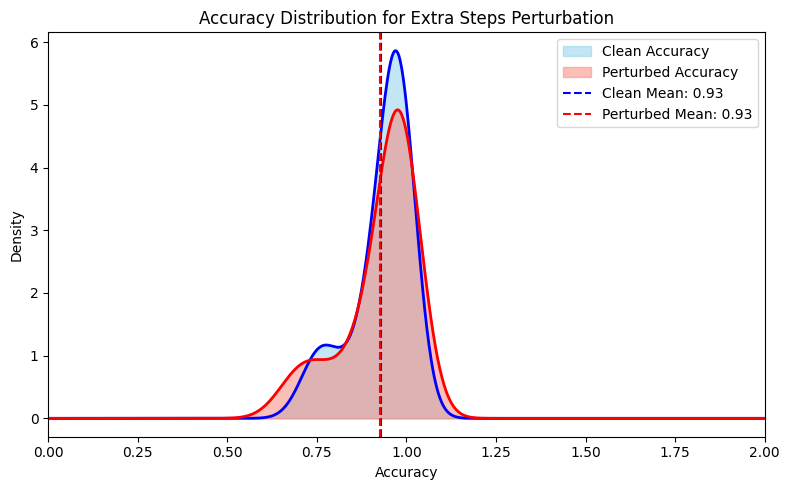


Math Error Perturbation:
  Clean Accuracy    - Mean: 0.9546, Std: 0.0492
  Perturbed Accuracy - Mean: 0.8700, Std: 0.1354


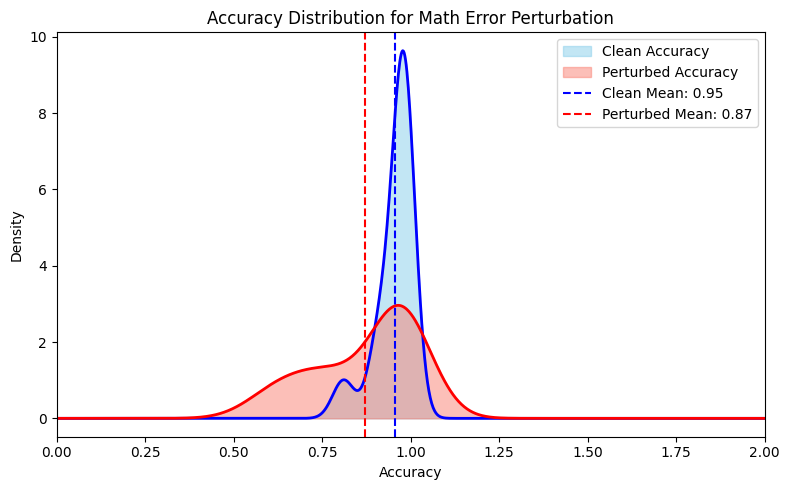


Skipped Steps Perturbation:
  Clean Accuracy    - Mean: 0.9431, Std: 0.0544
  Perturbed Accuracy - Mean: 0.9231, Std: 0.0797


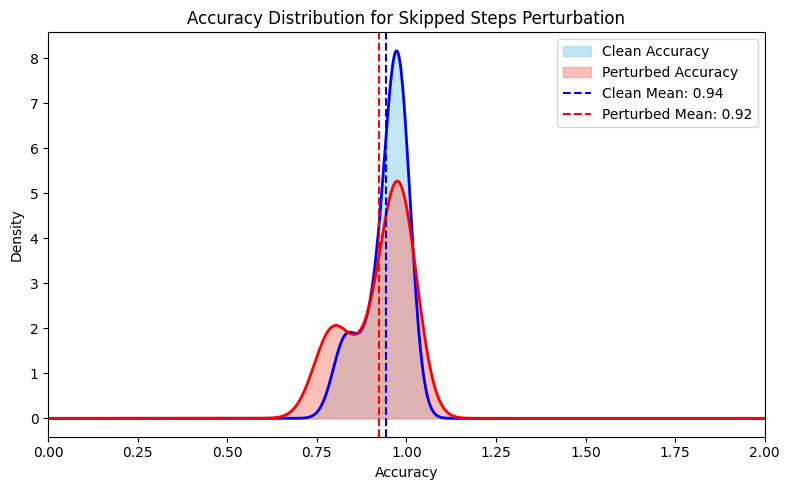


Sycophancy Perturbation:
  Clean Accuracy    - Mean: 0.9269, Std: 0.0674
  Perturbed Accuracy - Mean: 0.9346, Std: 0.0646


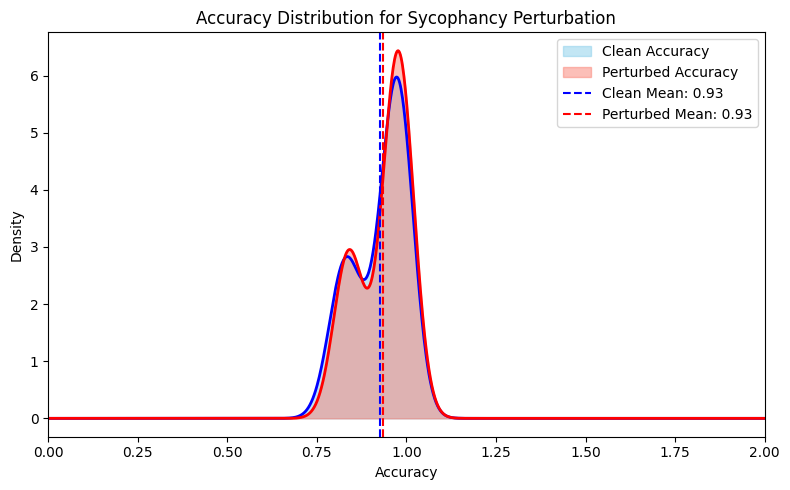


Unit Conversion Perturbation:
  Clean Accuracy    - Mean: 0.9323, Std: 0.0607
  Perturbed Accuracy - Mean: 0.9015, Std: 0.0699


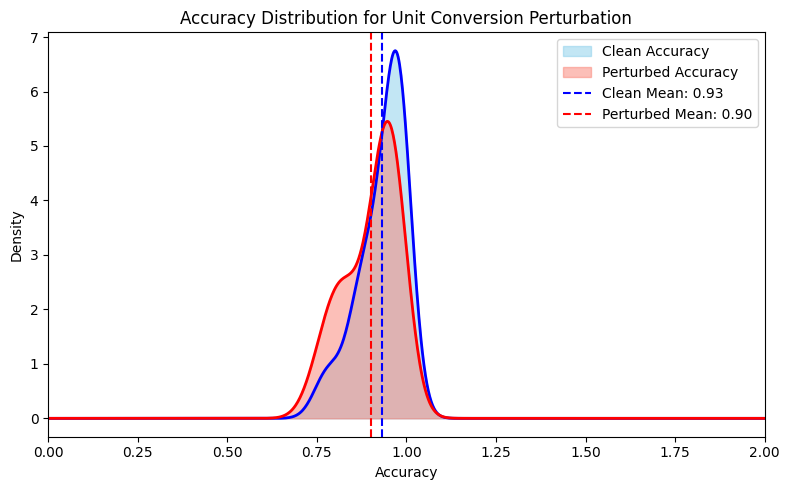

In [36]:
from scipy.stats import gaussian_kde

# perturbation wise density plot of accuracies for both clean and perturbed in different colours
for perturbation in perturbation_types:
    clean_accuracies = []
    perturbed_accuracies = []
    
    for model_name, model_data in accuracy_summary_no_ids.items():
        if perturbation in model_data and model_data[perturbation]:
            clean_acc = model_data[perturbation].get("clean_accuracy", None)
            perturbed_acc = model_data[perturbation].get("perturbed_accuracy", None)
            if clean_acc is not None and perturbed_acc is not None:
                clean_accuracies.append(clean_acc)
                perturbed_accuracies.append(perturbed_acc)
    
    # Print statistics
    print(f"\n{PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation:")
    print(f"  Clean Accuracy    - Mean: {np.mean(clean_accuracies):.4f}, Std: {np.std(clean_accuracies):.4f}")
    print(f"  Perturbed Accuracy - Mean: {np.mean(perturbed_accuracies):.4f}, Std: {np.std(perturbed_accuracies):.4f}")
    
    # Plot density plot
    fig, ax = plt.subplots(figsize=(8, 5))
    
    
    # Create density estimates
    if len(clean_accuracies) > 1:
        kde_clean = gaussian_kde(clean_accuracies)
        x_range = np.linspace(0, 2, 1000)
        ax.fill_between(x_range, kde_clean(x_range), alpha=0.5, label='Clean Accuracy', color='skyblue')
        ax.plot(x_range, kde_clean(x_range), color='blue', linewidth=2)
    
    if len(perturbed_accuracies) > 1:
        kde_perturbed = gaussian_kde(perturbed_accuracies)
        ax.fill_between(x_range, kde_perturbed(x_range), alpha=0.5, label='Perturbed Accuracy', color='salmon')
        ax.plot(x_range, kde_perturbed(x_range), color='red', linewidth=2)
    
    ax.axvline(np.mean(clean_accuracies), color='blue', linestyle='--', label=f'Clean Mean: {np.mean(clean_accuracies):.2f}')
    ax.axvline(np.mean(perturbed_accuracies), color='red', linestyle='--', label=f'Perturbed Mean: {np.mean(perturbed_accuracies):.2f}')
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Density')
    ax.set_title(f'Accuracy Distribution for {PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation')
    ax.legend()
    ax.set_xlim(0, 2)
    
    fig.tight_layout()
    plt.show()


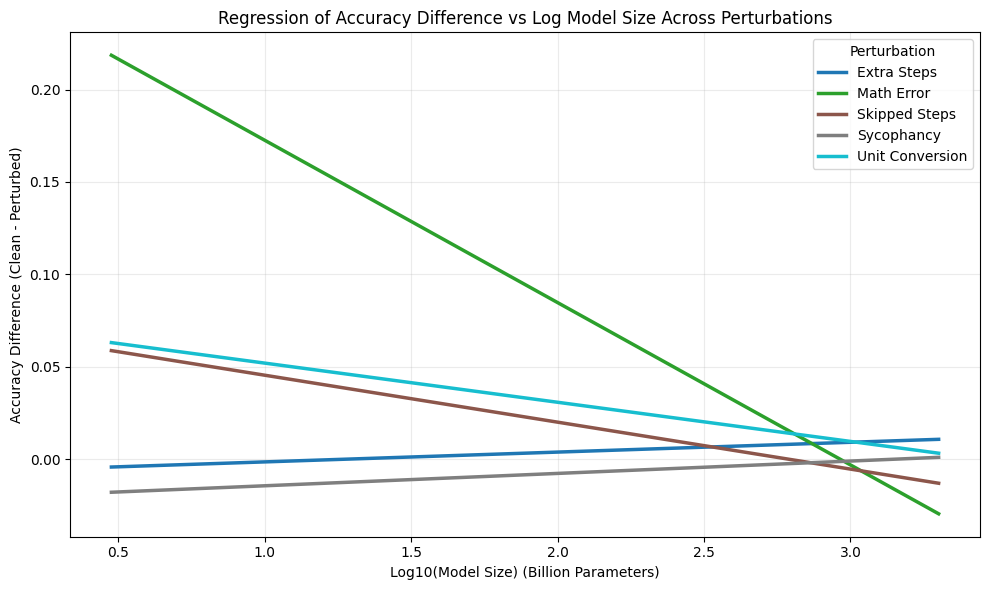

In [37]:
# Plot all perturbations together in one plot using regression lines only (log10 model size axis)
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(perturbation_types)))

for i, perturbation in enumerate(perturbation_types):
    model_sizes_log = []
    accuracy_diffs = []

    for model_name, model_data in accuracy_summary_no_ids.items():
        if perturbation in model_data and model_data[perturbation]:
            clean_acc = model_data[perturbation].get("clean_accuracy", None)
            perturbed_acc = model_data[perturbation].get("perturbed_accuracy", None)
            if clean_acc is not None and perturbed_acc is not None:
                size = MODEL_SIZE_MAP.get(model_name, None)
                if size is not None and size > 0:
                    model_sizes_log.append(math.log10(size))
                    accuracy_diffs.append(clean_acc - perturbed_acc)

    # Need at least two points to fit a line
    if len(model_sizes_log) > 1:
        z = np.polyfit(model_sizes_log, accuracy_diffs, 1)
        p = np.poly1d(z)

        x_line = np.linspace(min(model_sizes_log), max(model_sizes_log), 100)
        y_line = p(x_line)

        ax.plot(
            x_line,
            y_line,
            color=colors[i],
            linewidth=2.5,
            label=f"{PRESENTABLE_NAMES.get(perturbation, perturbation)}"
        )

ax.set_xlabel('Log10(Model Size) (Billion Parameters)')
ax.set_ylabel('Accuracy Difference (Clean - Perturbed)')
ax.set_title('Regression of Accuracy Difference vs Log Model Size Across Perturbations')
ax.legend(title='Perturbation',loc='upper right')
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

# Save combined figure
os.makedirs("result_plots_with_error_hint/accuracy_vs_model_size", exist_ok=True)
fig.savefig("result_plots_with_error_hint/accuracy_vs_model_size/all_perturbations_regression_lines.png", dpi=300, bbox_inches='tight')


Extra Steps Perturbation:
  90th percentile: 0.0840
  95th percentile: 0.1200
  99th percentile: 0.1440

  Models above 90th percentile (most affected):
    mistralai_mistral_large_2512: 0.1000

  Models above 95th percentile (most affected):

  Models above 99th percentile (most affected):
    mistralai_ministral_3b: 0.1500


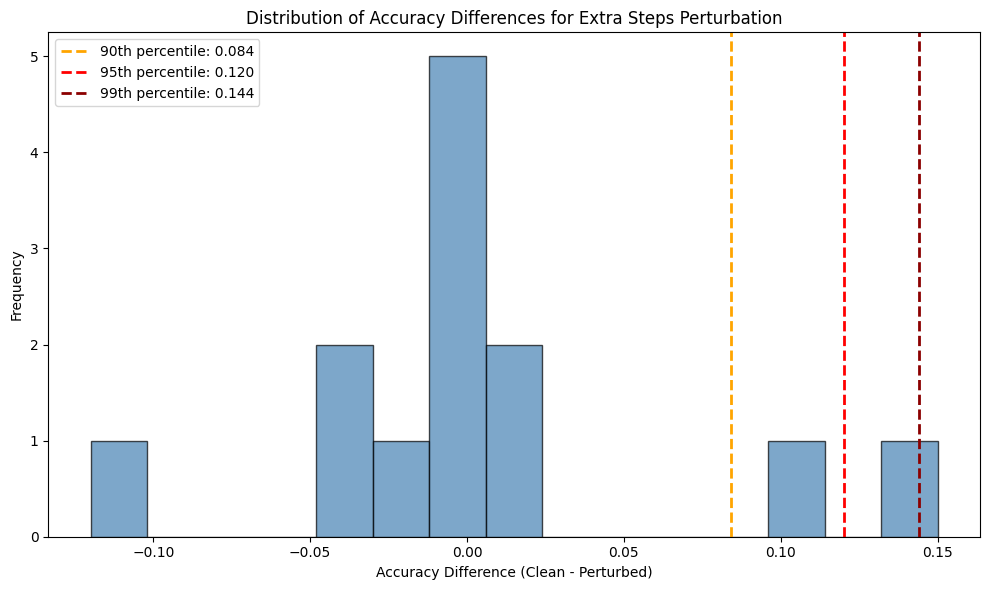


Math Error Perturbation:
  90th percentile: 0.2780
  95th percentile: 0.3040
  99th percentile: 0.3088

  Models above 90th percentile (most affected):
    meta_llama_llama_3_1_8b_instruct: 0.3000

  Models above 95th percentile (most affected):

  Models above 99th percentile (most affected):
    google_gemma_3_4b_it: 0.3100


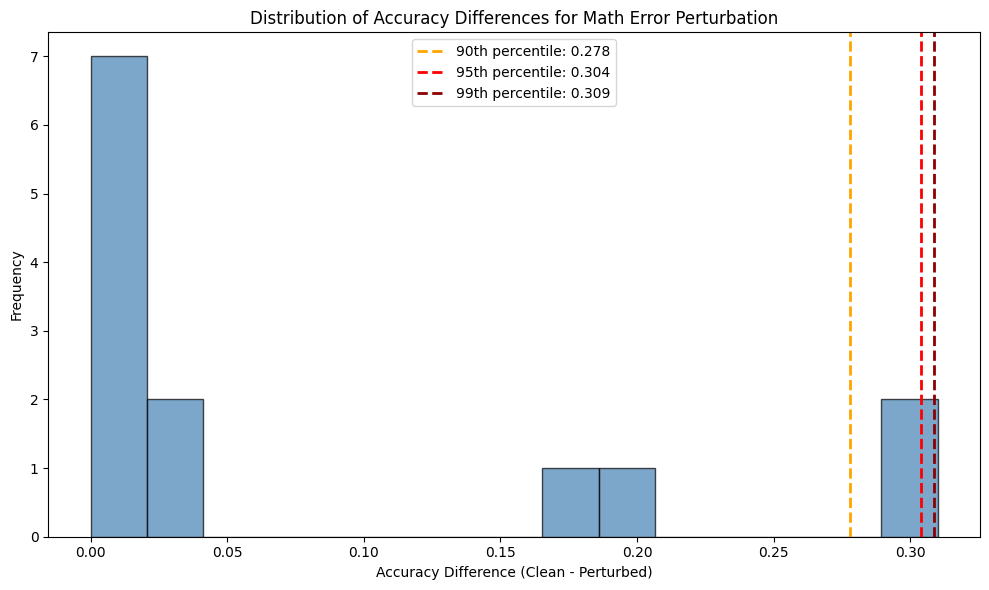


Skipped Steps Perturbation:
  90th percentile: 0.1160
  95th percentile: 0.1520
  99th percentile: 0.1664

  Models above 90th percentile (most affected):
    mistralai_ministral_3b: 0.1400

  Models above 95th percentile (most affected):

  Models above 99th percentile (most affected):
    mistralai_ministral_8b_2512: 0.1700


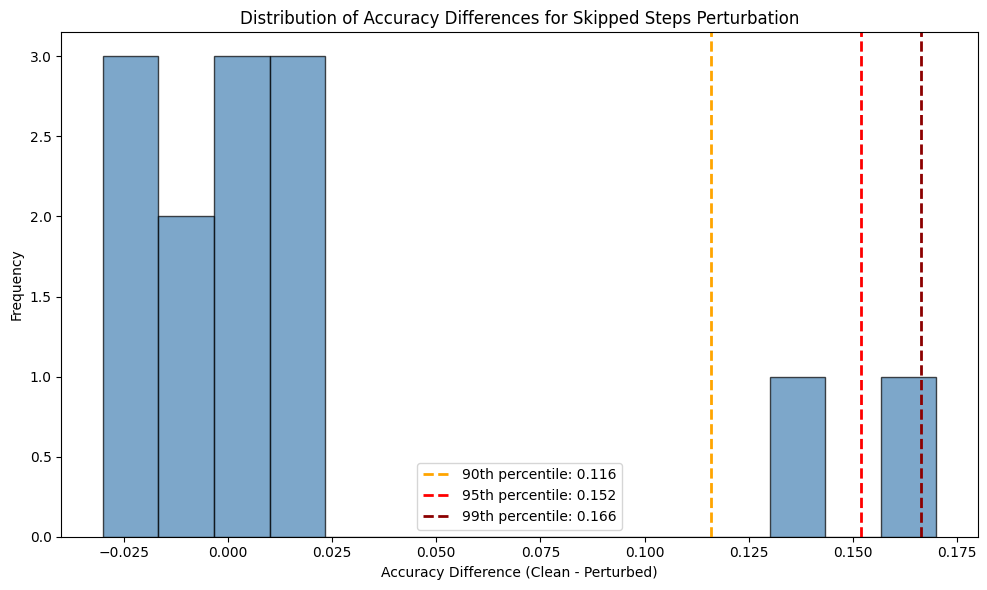


Sycophancy Perturbation:
  90th percentile: 0.0180
  95th percentile: 0.0200
  99th percentile: 0.0200

  Models above 90th percentile (most affected):

  Models above 95th percentile (most affected):

  Models above 99th percentile (most affected):
    mistralai_ministral_3b: 0.0200
    openai_gpt_5_2: 0.0200


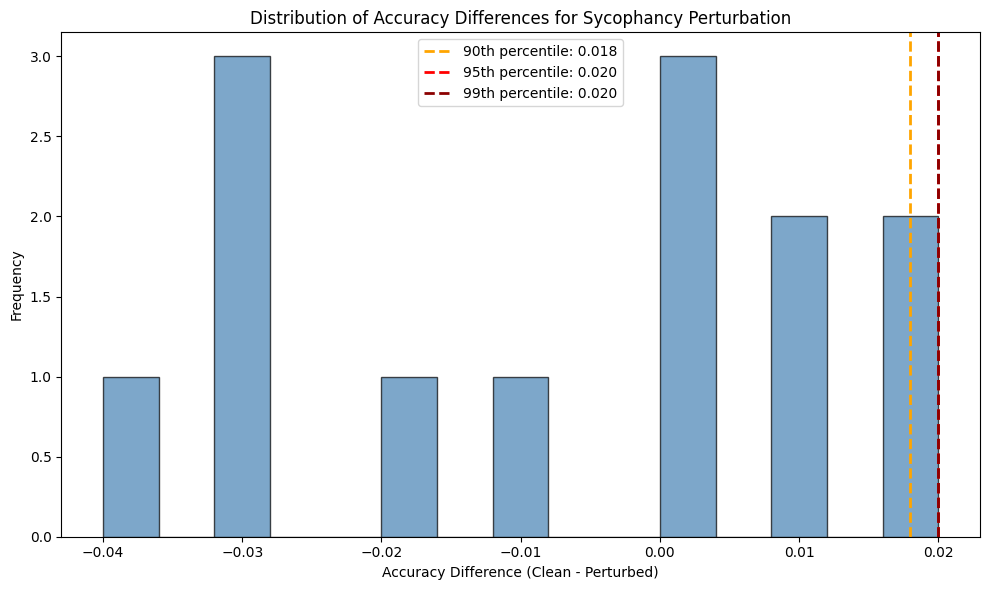


Unit Conversion Perturbation:
  90th percentile: 0.0940
  95th percentile: 0.1040
  99th percentile: 0.1088

  Models above 90th percentile (most affected):
    google_gemma_3_4b_it: 0.1000

  Models above 95th percentile (most affected):

  Models above 99th percentile (most affected):
    openai_gpt_4o_mini: 0.1100


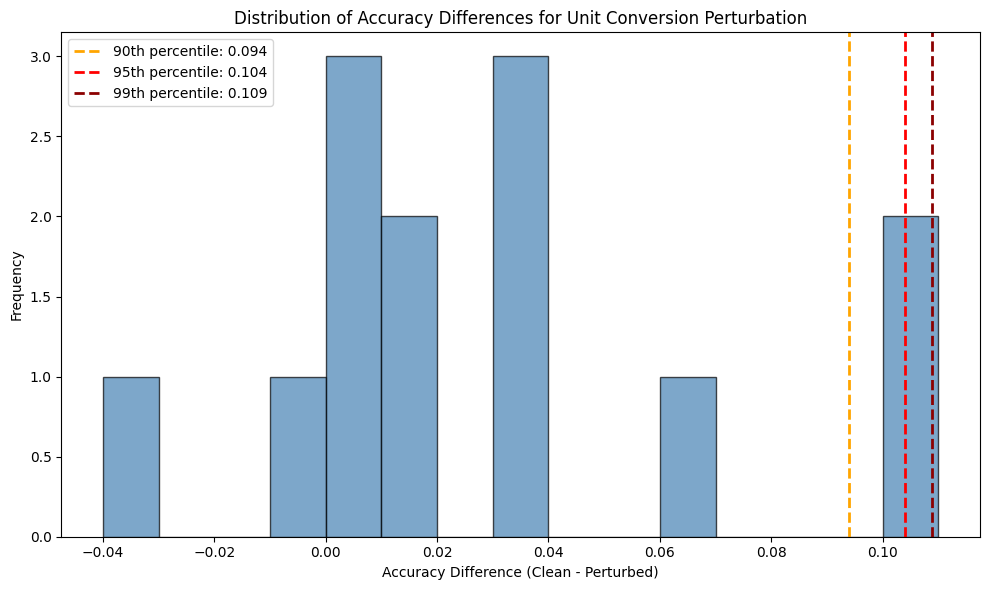

In [38]:
# For each perturbation, plot the histogram of accuracy differences across the models
# identify the models which are significantly affected by the perturbation (90, 95 and 99 percentiles)

for perturbation in perturbation_types:
    accuracy_diffs = []
    model_names = []
    
    for model_name, model_data in accuracy_summary_no_ids.items():
        if perturbation in model_data and model_data[perturbation]:
            clean_acc = model_data[perturbation].get("clean_accuracy", None)
            perturbed_acc = model_data[perturbation].get("perturbed_accuracy", None)
            if clean_acc is not None and perturbed_acc is not None:
                accuracy_diff = clean_acc - perturbed_acc
                accuracy_diffs.append(accuracy_diff)
                model_names.append(model_name)
    
    if len(accuracy_diffs) == 0:
        continue
    
    # Calculate percentiles
    p90 = np.percentile(accuracy_diffs, 90)
    p95 = np.percentile(accuracy_diffs, 95)
    p99 = np.percentile(accuracy_diffs, 99)
    
    print(f"\n{PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation:")
    print(f"  90th percentile: {p90:.4f}")
    print(f"  95th percentile: {p95:.4f}")
    print(f"  99th percentile: {p99:.4f}")
    
    # Identify models above each percentile
    print(f"\n  Models above 90th percentile (most affected):")
    for i, diff in enumerate(accuracy_diffs):
        if diff >= p90 and diff < p95:
            print(f"    {model_names[i]}: {diff:.4f}")

    print(f"\n  Models above 95th percentile (most affected):")
    for i, diff in enumerate(accuracy_diffs):
        if diff >= p95 and diff < p99:
            print(f"    {model_names[i]}: {diff:.4f}")
    
    print(f"\n  Models above 99th percentile (most affected):")
    for i, diff in enumerate(accuracy_diffs):
        if diff >= p99:
            print(f"    {model_names[i]}: {diff:.4f}")
    
    # Plot histogram
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(accuracy_diffs, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
    
    # Add percentile lines
    ax.axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {p90:.3f}')
    ax.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'95th percentile: {p95:.3f}')
    ax.axvline(p99, color='darkred', linestyle='--', linewidth=2, label=f'99th percentile: {p99:.3f}')
    
    ax.set_xlabel('Accuracy Difference (Clean - Perturbed)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Accuracy Differences for {PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation')
    ax.legend()
    
    fig.tight_layout()
    plt.show()
    
    # Save the figure
    os.makedirs("result_plots_with_error_hint/accuracy_diff_histogram", exist_ok=True)
    fig.savefig(f"result_plots_with_error_hint/accuracy_diff_histogram/{perturbation}.png")


Extra Steps Perturbation:
  10th percentile robustness: 0.8947
   5th percentile robustness: 0.8581
   1st percentile robustness: 0.8398

  Models below 10th percentile (affected):
    mistralai_mistral_large_2512: 0.8734

  Models below 5th percentile (highly affected):

  Models below 1st percentile (most affected):
    mistralai_ministral_3b: 0.8352


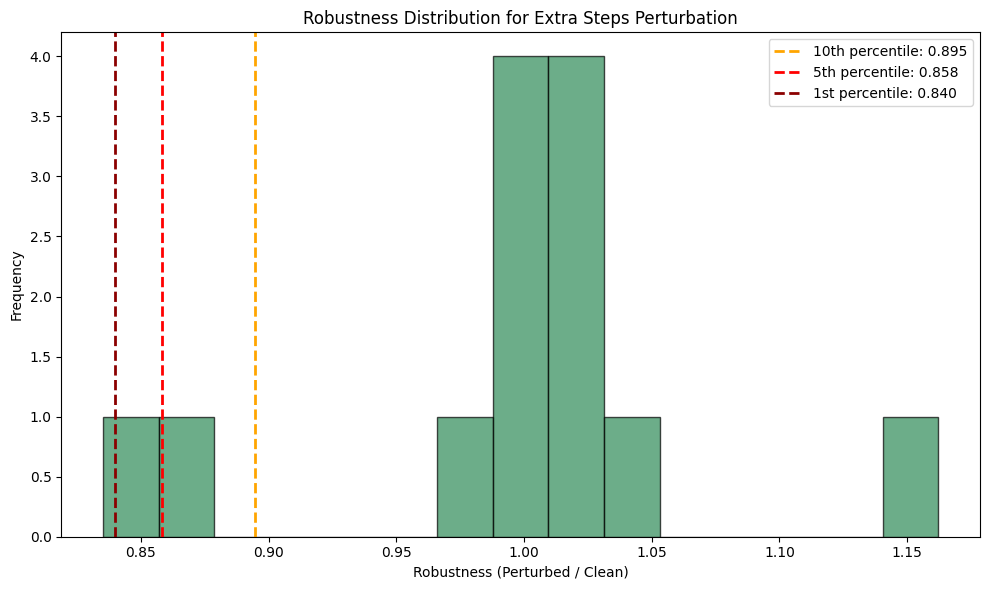


Math Error Perturbation:
  10th percentile robustness: 0.7056
   5th percentile robustness: 0.6743
   1st percentile robustness: 0.6623

  Models below 10th percentile (affected):
    meta_llama_llama_3_1_8b_instruct: 0.6842

  Models below 5th percentile (highly affected):

  Models below 1st percentile (most affected):
    google_gemma_3_4b_it: 0.6593


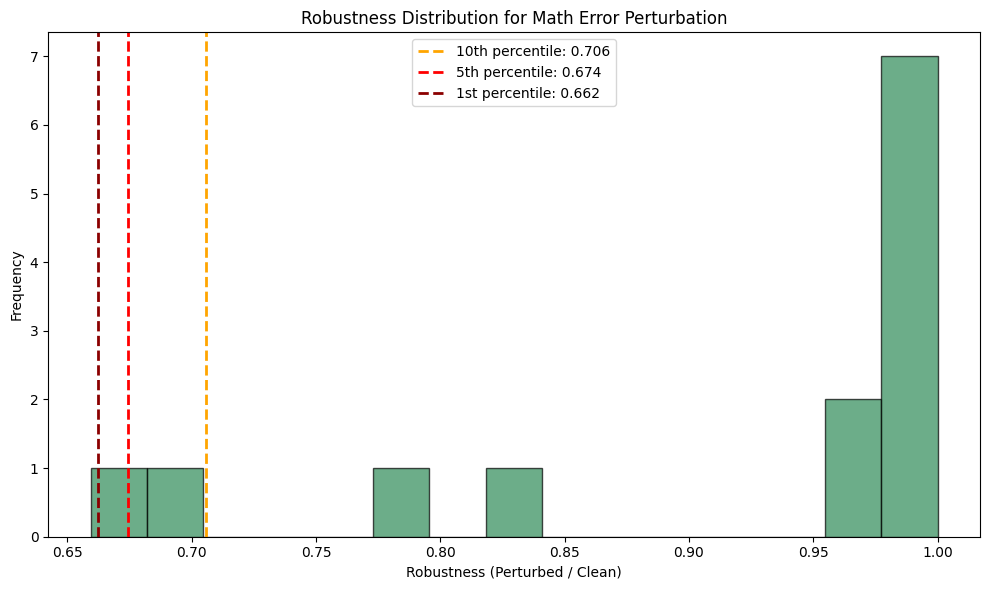


Skipped Steps Perturbation:
  10th percentile robustness: 0.8734
   5th percentile robustness: 0.8379
   1st percentile robustness: 0.8259

  Models below 10th percentile (affected):
    mistralai_ministral_3b: 0.8478

  Models below 5th percentile (highly affected):

  Models below 1st percentile (most affected):
    mistralai_ministral_8b_2512: 0.8229


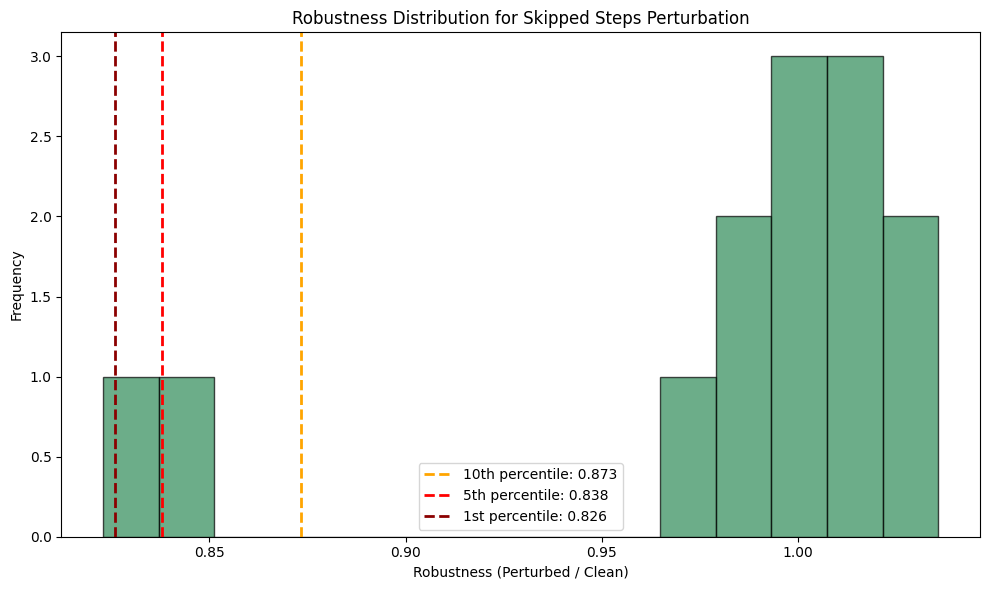


Sycophancy Perturbation:
  10th percentile robustness: 0.9815
   5th percentile robustness: 0.9785
   1st percentile robustness: 0.9769

  Models below 10th percentile (affected):
    openai_gpt_5_2: 0.9798

  Models below 5th percentile (highly affected):

  Models below 1st percentile (most affected):
    mistralai_ministral_3b: 0.9765


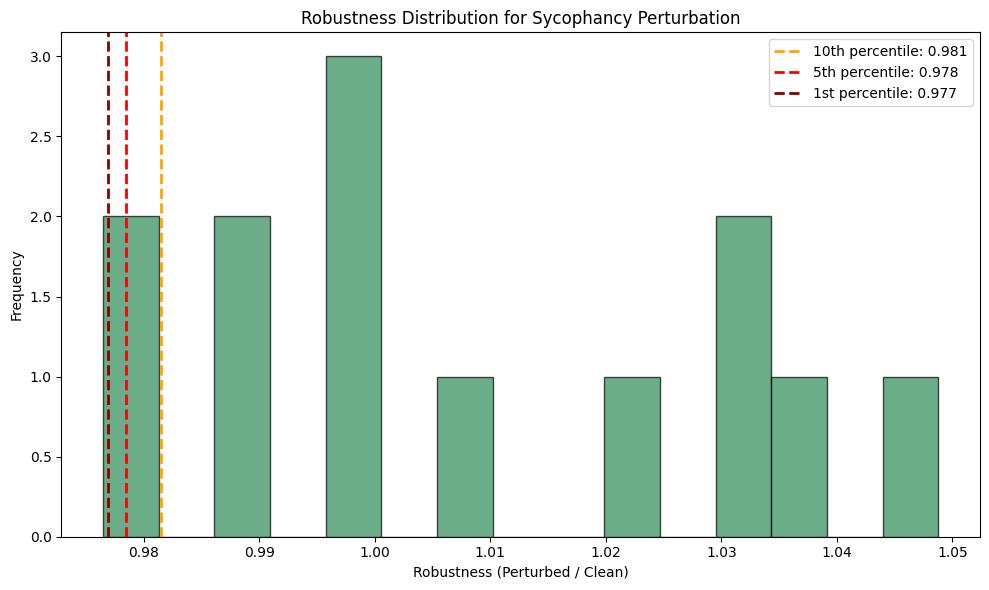


Unit Conversion Perturbation:
  10th percentile robustness: 0.8913
   5th percentile robustness: 0.8840
   1st percentile robustness: 0.8838

  Models below 10th percentile (affected):
    openai_gpt_4o_mini: 0.8842

  Models below 5th percentile (highly affected):

  Models below 1st percentile (most affected):
    google_gemma_3_4b_it: 0.8837


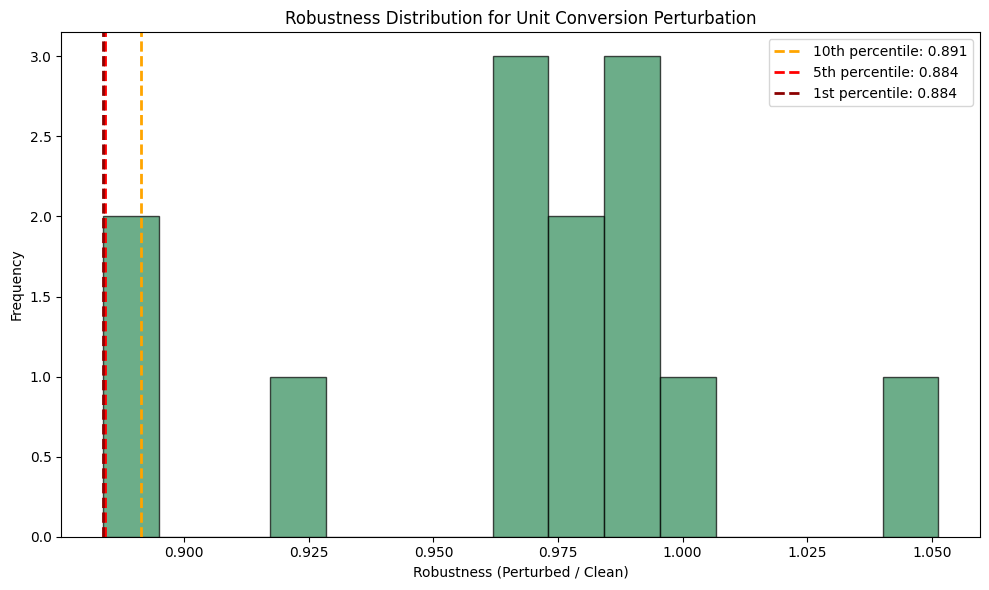

In [39]:
# For each perturbation, plot histogram of robustness across models
# robustness = perturbed_accuracy / clean_accuracy
# lower robustness => more affected by perturbation

for perturbation in perturbation_types:
    robustness_values = []
    model_names = []
    
    for model_name, model_data in accuracy_summary_no_ids.items():
        if perturbation in model_data and model_data[perturbation]:
            clean_acc = model_data[perturbation].get("clean_accuracy", None)
            perturbed_acc = model_data[perturbation].get("perturbed_accuracy", None)
            if clean_acc is not None and perturbed_acc is not None and clean_acc > 0:
                robustness = perturbed_acc / clean_acc
                robustness_values.append(robustness)
                model_names.append(model_name)
    
    if len(robustness_values) == 0:
        continue
    
    # Lower tail percentiles (most affected models)
    p10 = np.percentile(robustness_values, 10)
    p5 = np.percentile(robustness_values, 5)
    p1 = np.percentile(robustness_values, 1)
    
    print(f"\n{PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation:")
    print(f"  10th percentile robustness: {p10:.4f}")
    print(f"   5th percentile robustness: {p5:.4f}")
    print(f"   1st percentile robustness: {p1:.4f}")
    
    print(f"\n  Models below 10th percentile (affected):")
    for i, r in enumerate(robustness_values):
        if p5 < r <= p10:
            print(f"    {model_names[i]}: {r:.4f}")

    print(f"\n  Models below 5th percentile (highly affected):")
    for i, r in enumerate(robustness_values):
        if p1 < r <= p5:
            print(f"    {model_names[i]}: {r:.4f}")
    
    print(f"\n  Models below 1st percentile (most affected):")
    for i, r in enumerate(robustness_values):
        if r <= p1:
            print(f"    {model_names[i]}: {r:.4f}")
    
    # Plot histogram
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(robustness_values, bins=15, edgecolor='black', alpha=0.7, color='seagreen')
    
    # Add percentile lines
    ax.axvline(p10, color='orange', linestyle='--', linewidth=2, label=f'10th percentile: {p10:.3f}')
    ax.axvline(p5, color='red', linestyle='--', linewidth=2, label=f'5th percentile: {p5:.3f}')
    ax.axvline(p1, color='darkred', linestyle='--', linewidth=2, label=f'1st percentile: {p1:.3f}')
    
    ax.set_xlabel('Robustness (Perturbed / Clean)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Robustness Distribution for {PRESENTABLE_NAMES.get(perturbation, perturbation)} Perturbation')
    ax.legend()
    
    fig.tight_layout()
    plt.show()
    
    # Save figure
    os.makedirs("result_plots_with_error_hint/robustness_histogram", exist_ok=True)
    fig.savefig(f"result_plots_with_error_hint/robustness_histogram/{perturbation}.png")

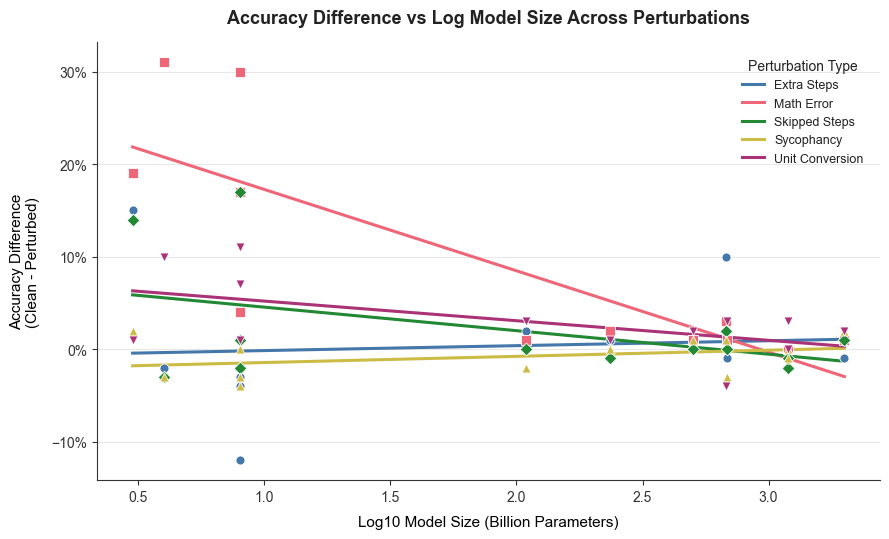

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import math
import os

# â”€â”€ Style overrides â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.8,
    "xtick.color":       "#333333",
    "ytick.color":       "#333333",
    "text.color":        "#222222",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "legend.frameon":    False,
})

fig, ax = plt.subplots(figsize=(9, 5.5))

# â”€â”€ Color palette (colorblind-friendly, distinct) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PALETTE = {
    "Extra Steps":     "#4477AA",   # muted blue
    "Math Error":      "#EE6677",   # soft red
    "Skipped Steps":   "#228833",   # green
    "Sycophancy":      "#CCBB44",   # gold
    "Unit Conversion": "#AA3377",   # purple
}
MARKER_STYLE = {
    "Extra Steps":     "o",
    "Math Error":      "s",
    "Skipped Steps":   "D",
    "Sycophancy":      "^",
    "Unit Conversion": "v",
}

for perturbation in perturbation_types:
    model_sizes_log = []
    accuracy_diffs = []

    for model_name, model_data in accuracy_summary_no_ids.items():
        if perturbation in model_data and model_data[perturbation]:
            clean_acc = model_data[perturbation].get("clean_accuracy")
            perturbed_acc = model_data[perturbation].get("perturbed_accuracy")
            if clean_acc is not None and perturbed_acc is not None:
                size = MODEL_SIZE_MAP.get(model_name)
                if size is not None and size > 0:
                    model_sizes_log.append(math.log10(size))
                    accuracy_diffs.append(clean_acc - perturbed_acc)

    label = PRESENTABLE_NAMES.get(perturbation, perturbation)
    color = PALETTE.get(label, "#999999")
    marker = MARKER_STYLE.get(label, "o")

    # â”€â”€ Scatter the actual data points â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    ax.scatter(
        model_sizes_log, accuracy_diffs,
        color=color, marker=marker, s=42,
        edgecolors="white", linewidths=0.6,
        zorder=3,                       # on top of grid
    )

    # â”€â”€ Regression line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(model_sizes_log) > 1:
        z = np.polyfit(model_sizes_log, accuracy_diffs, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min(model_sizes_log), max(model_sizes_log), 200)

        ax.plot(
            x_line, p(x_line),
            color=color, linewidth=2.2, label=label, zorder=2,
        )

        # # â”€â”€ Light confidence band (Â±1 SE of residuals) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        # residuals = np.array(accuracy_diffs) - p(np.array(model_sizes_log))
        # se = np.std(residuals)
        # ax.fill_between(
        #     x_line, p(x_line) - se, p(x_line) + se,
        #     color=color, alpha=0.08, zorder=1,
        # )

# â”€â”€ Axes labels & title â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax.set_xlabel("Log10 Model Size (Billion Parameters)", fontsize=11, labelpad=8)
ax.set_ylabel("Accuracy Difference\n(Clean - Perturbed)", fontsize=11, labelpad=8)
ax.set_title(
    "Accuracy Difference vs Log Model Size Across Perturbations",
    fontsize=13, fontweight="bold", pad=14,
)

# â”€â”€ Subtle grid â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="y", color="#dddddd", linewidth=0.5)
ax.set_axisbelow(True)

# â”€â”€ Legend â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
leg = ax.legend(
    title="Perturbation Type", title_fontsize=10,
    fontsize=9, loc="upper right",
    borderpad=0.8, handlelength=1.8,
)

fig.tight_layout()
plt.show()

# â”€â”€ Save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
os.makedirs("result_plots_with_error_hint/accuracy_vs_model_size", exist_ok=True)
fig.savefig(
    "result_plots_with_error_hint/accuracy_vs_model_size/all_perturbations_regression_lines.png",
    dpi=300, bbox_inches="tight",
)

Rows used: 65
Models used: 13
Perturbations used: 5
                            OLS Regression Results                            
Dep. Variable:          accuracy_diff   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     2.990
Date:                Tue, 23 Jun 2026   Prob (F-statistic):            0.00570
Time:                        23:55:54   Log-Likelihood:                 103.23
No. Observations:                  65   AIC:                            -186.5
Df Residuals:                      55   BIC:                            -164.7
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

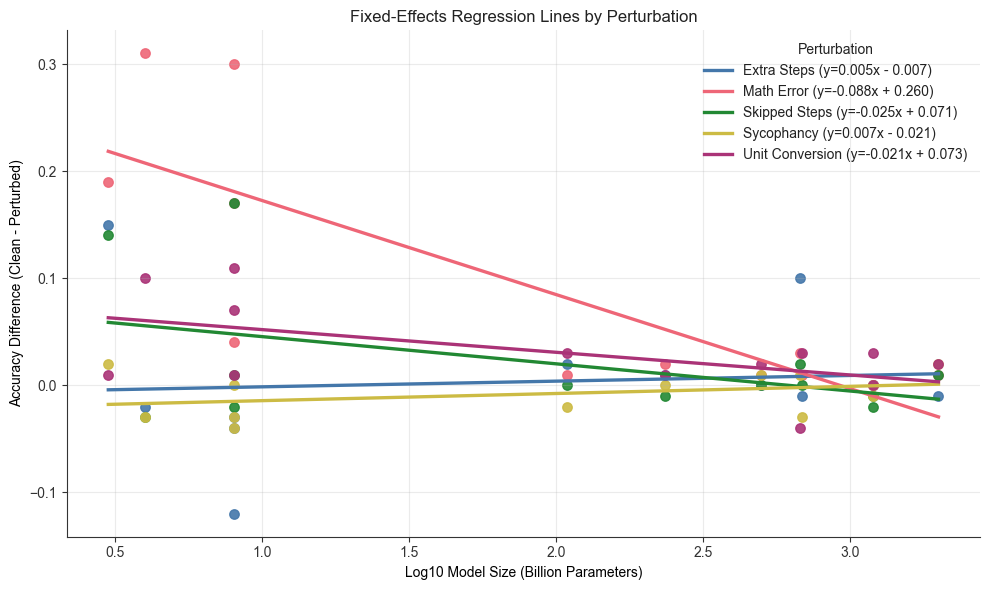

In [41]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import math

# Build panel-style data: one row per (model, perturbation)
rows = []
for model_name, model_data in accuracy_summary_no_ids.items():
    size = MODEL_SIZE_MAP.get(model_name)
    if size is None or size <= 0:
        continue

    log_size = math.log10(size)
    for perturbation, metrics in model_data.items():
        clean_acc = metrics.get("clean_accuracy")
        perturbed_acc = metrics.get("perturbed_accuracy")
        if clean_acc is None or perturbed_acc is None:
            continue

        rows.append({
            "model": model_name,
            "perturbation": perturbation,
            "log_model_size": log_size,
            "accuracy_diff": clean_acc - perturbed_acc,
        })

df_fe = pd.DataFrame(rows)
if df_fe.empty:
    raise ValueError("No rows available for fixed-effects regression.")

print(f"Rows used: {len(df_fe)}")
print(f"Models used: {df_fe['model'].nunique()}")
print(f"Perturbations used: {df_fe['perturbation'].nunique()}")

# Fixed-effects regression: perturbation controls + size-by-perturbation interactions
fe_model = smf.ols(
    "accuracy_diff ~ log_model_size + C(perturbation) + log_model_size:C(perturbation)",
    data=df_fe,
).fit(cov_type='HC3')  # Robust SEs to account for heteroskedasticity

print(fe_model.summary())

# Significance test for all size-related terms (main + interactions)
size_terms = [term for term in fe_model.params.index if term.startswith("log_model_size")]
constraint = ", ".join([f"{term} = 0" for term in size_terms])
test_size_terms = fe_model.f_test(constraint)
print("\nJoint F-test for size effects (main + interactions):")
print(test_size_terms)

# Plot fitted lines for each perturbation with lighter, colorful tones
fig, ax = plt.subplots(figsize=(10, 6))
perturbations_sorted = sorted(df_fe["perturbation"].unique())
bright_palette = [
    # "#FF8FAB",  # light pink
    # "#6BCBFF",  # light sky blue
    # "#95E06C",  # light lime green
    # "#FFB86B",  # light orange
    # "#C792EA",  # light violet
    # "#4DE6C3",  # mint teal
    # "#FFE66D",  # soft yellow
    # "#7FB3FF",  # periwinkle blue

    "#4477AA",   # muted blue
    "#EE6677",   # soft red
    "#228833",   # green
    "#CCBB44",   # gold
    "#AA3377",   # purple
]
colors = [bright_palette[i % len(bright_palette)] for i in range(len(perturbations_sorted))]

params = fe_model.params
base_intercept = params.get("Intercept", 0.0)
base_slope = params.get("log_model_size", 0.0)

for color, perturbation in zip(colors, perturbations_sorted):
    df_sub = df_fe[df_fe["perturbation"] == perturbation].copy()
    ax.scatter(
        df_sub["log_model_size"],
        df_sub["accuracy_diff"],
        color=color,
        alpha=0.9,
        s=46,
    )

    x_grid = np.linspace(df_sub["log_model_size"].min(), df_sub["log_model_size"].max(), 120)
    pred_df = pd.DataFrame({
        "log_model_size": x_grid,
        "perturbation": perturbation,
    })
    y_hat = fe_model.predict(pred_df)

    # Extract perturbation-specific line equation from FE coefficients
    intercept_term = params.get(f"C(perturbation)[T.{perturbation}]", 0.0)
    slope_term = params.get(f"log_model_size:C(perturbation)[T.{perturbation}]", 0.0)
    if slope_term == 0.0:
        slope_term = params.get(f"C(perturbation)[T.{perturbation}]:log_model_size", 0.0)

    perturbation_intercept = base_intercept + intercept_term
    perturbation_slope = base_slope + slope_term

    eq_sign = "+" if perturbation_intercept >= 0 else "-"
    equation = f"y={perturbation_slope:.3f}x {eq_sign} {abs(perturbation_intercept):.3f}"

    display_name = PRESENTABLE_NAMES.get(perturbation, perturbation)
    label = f"{display_name} ({equation})"
    ax.plot(x_grid, y_hat, color=color, linewidth=2.4, label=label)

ax.set_xlabel("Log10 Model Size (Billion Parameters)")
ax.set_ylabel("Accuracy Difference (Clean - Perturbed)")
ax.set_title("Fixed-Effects Regression Lines by Perturbation")
ax.grid(alpha=0.25)
ax.legend(title="Perturbation", loc="best")
fig.tight_layout()
plt.savefig("result_plots_with_error_hint/accuracy_vs_model_size/fe_regression_lines.png", dpi=300, bbox_inches='tight')
plt.show()

Rows used: 65
Models used: 13
Perturbations used: 5
                            OLS Regression Results                            
Dep. Variable:             robustness   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     2.871
Date:                Tue, 23 Jun 2026   Prob (F-statistic):            0.00751
Time:                        23:55:55   Log-Likelihood:                 95.602
No. Observations:                  65   AIC:                            -171.2
Df Residuals:                      55   BIC:                            -149.5
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

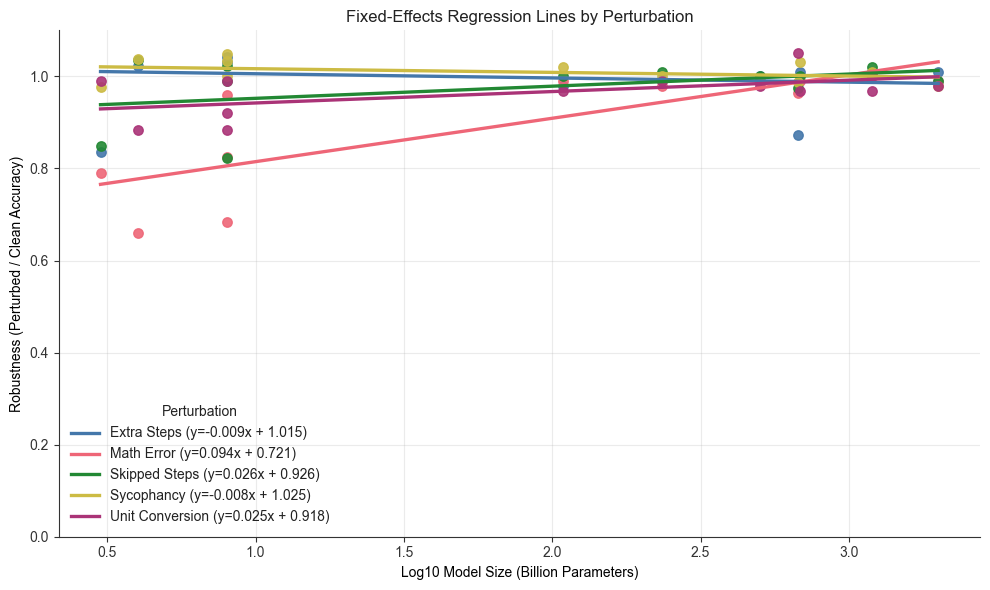

In [42]:
rows = []
for model_name, model_data in accuracy_summary_no_ids.items():
    size = MODEL_SIZE_MAP.get(model_name)
    if size is None or size <= 0:
        continue

    log_size = math.log10(size)
    for perturbation, metrics in model_data.items():
        clean_acc = metrics.get("clean_accuracy")
        perturbed_acc = metrics.get("perturbed_accuracy")
        if clean_acc is None or perturbed_acc is None or clean_acc == 0:
            continue

        rows.append({
            "model": model_name,
            "perturbation": perturbation,
            "log_model_size": log_size,
            "robustness": perturbed_acc / clean_acc,
        })

df_fe = pd.DataFrame(rows)
if df_fe.empty:
    raise ValueError("No rows available for fixed-effects regression.")

print(f"Rows used: {len(df_fe)}")
print(f"Models used: {df_fe['model'].nunique()}")
print(f"Perturbations used: {df_fe['perturbation'].nunique()}")

fe_model = smf.ols(
    "robustness ~ log_model_size + C(perturbation) + log_model_size:C(perturbation)",
    data=df_fe,
).fit(cov_type="HC3")

print(fe_model.summary())

size_terms = [term for term in fe_model.params.index if term.startswith("log_model_size")]
constraint = ", ".join([f"{term} = 0" for term in size_terms])
test_size_terms = fe_model.f_test(constraint)
print("\nJoint F-test for size effects (main + interactions):")
print(test_size_terms)

fig, ax = plt.subplots(figsize=(10, 6))
perturbations_sorted = sorted(df_fe["perturbation"].unique())
colors = [bright_palette[i % len(bright_palette)] for i in range(len(perturbations_sorted))]

params = fe_model.params
base_intercept = params.get("Intercept", 0.0)
base_slope = params.get("log_model_size", 0.0)

for color, perturbation in zip(colors, perturbations_sorted):
    df_sub = df_fe[df_fe["perturbation"] == perturbation].copy()
    ax.scatter(
        df_sub["log_model_size"],
        df_sub["robustness"],
        color=color,
        alpha=0.9,
        s=46,
    )

    x_grid = np.linspace(df_sub["log_model_size"].min(), df_sub["log_model_size"].max(), 120)
    pred_df = pd.DataFrame({
        "log_model_size": x_grid,
        "perturbation": perturbation,
    })
    y_hat = fe_model.predict(pred_df)

    intercept_term = params.get(f"C(perturbation)[T.{perturbation}]", 0.0)
    slope_term = params.get(f"log_model_size:C(perturbation)[T.{perturbation}]", 0.0)
    if slope_term == 0.0:
        slope_term = params.get(f"C(perturbation)[T.{perturbation}]:log_model_size", 0.0)

    perturbation_intercept = base_intercept + intercept_term
    perturbation_slope = base_slope + slope_term

    eq_sign = "+" if perturbation_intercept >= 0 else "-"
    equation = f"y={perturbation_slope:.3f}x {eq_sign} {abs(perturbation_intercept):.3f}"

    display_name = PRESENTABLE_NAMES.get(perturbation, perturbation)
    label = f"{display_name} ({equation})"
    ax.plot(x_grid, y_hat, color=color, linewidth=2.4, label=label)

ax.set_xlabel("Log10 Model Size (Billion Parameters)")
ax.set_ylabel("Robustness (Perturbed / Clean Accuracy)")
ax.set_title("Fixed-Effects Regression Lines by Perturbation")
ax.set_ylim(0, 1.1)
ax.grid(alpha=0.25)
ax.legend(title="Perturbation", loc="best")
fig.tight_layout()
os.makedirs("result_plots_with_error_hint/robustness_vs_model_size", exist_ok=True)
plt.savefig("result_plots_with_error_hint/robustness_vs_model_size/fe_regression_lines.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
# Combined accuracy/robustness table as a single LaTeX table,
# columns grouped by perturbation. Rows = models, plus an Average row.
METRICS = ["Clean", "Perturbed", "Diff", "Robustness"]
n_metrics = len(METRICS)

# Column spec: model column + one |cccc| block per perturbation
col_spec = "l|" + "|".join(["c" * n_metrics for _ in perturbation_types]) + "|"

latex = []
latex.append("\\begin{table}[h]")
latex.append("\\centering")
latex.append("\\resizebox{\\textwidth}{!}{%")
latex.append("\\begin{tabular}{" + col_spec + "}")
latex.append("\\hline")

# Group-header row: \multicolumn{4}{c}{Perturbation} per perturbation
group_cells = ["\\multicolumn{%d}{c|}{%s}" % (n_metrics, PRESENTABLE_NAMES.get(p, p))
               for p in perturbation_types]
latex.append("Model & " + " & ".join(group_cells) + " \\\\")

# Metric sub-header row
metric_cells = " & ".join(METRICS)
latex.append(" & " + " & ".join([metric_cells for _ in perturbation_types]) + " \\\\")
latex.append("\\hline")

# Accumulators for the Average row
sums = {p: {m: [] for m in METRICS} for p in perturbation_types}

for model_name, model_data in accuracy_summary_no_ids.items():
    display_name = model_name.replace("_", " ").title()
    cells = [display_name]
    for pert in perturbation_types:
        clean = perturbed = diff = robustness = None
        if pert in model_data and model_data[pert]:
            c = model_data[pert].get("clean_accuracy", "")
            p = model_data[pert].get("perturbed_accuracy", "")
            if c != "" and p != "" and c is not None and p is not None:
                clean, perturbed = c, p
                diff = perturbed - clean
                robustness = min(1, perturbed / clean) if clean > 0 else None

        if clean is None:
            cells += ["--", "--", "--", "--"]
        else:
            cells += [f"{clean:.2f}", f"{perturbed:.2f}", f"{diff:+.2f}", f"{robustness:.3f}"]
            sums[pert]["Clean"].append(clean)
            sums[pert]["Perturbed"].append(perturbed)
            sums[pert]["Diff"].append(diff)
            sums[pert]["Robustness"].append(robustness)
    latex.append(" & ".join(cells) + " \\\\")

# Average row
latex.append("\\hline")
avg_cells = ["Average"]
for pert in perturbation_types:
    if sums[pert]["Clean"]:
        avg_cells += [
            f"{np.mean(sums[pert]['Clean']):.3f}",
            f"{np.mean(sums[pert]['Perturbed']):.3f}",
            f"{np.mean(sums[pert]['Diff']):+.3f}",
            f"{np.mean(sums[pert]['Robustness']):.3f}",
        ]
    else:
        avg_cells += ["--", "--", "--", "--"]
latex.append(" & ".join(avg_cells) + " \\\\")
latex.append("\\hline")

latex.append("\\end{tabular}%")
latex.append("}")
latex.append("\\caption{Combined model accuracy and robustness across all perturbations.}")
latex.append("\\label{tab:combined_accuracy_robustness}")
latex.append("\\end{table}")

combined_latex = "\n".join(latex)
print(combined_latex)


\begin{table}[h]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cccc|cccc|cccc|cccc|cccc|}
\hline
Model & \multicolumn{4}{c|}{Extra Steps} & \multicolumn{4}{c|}{Math Error} & \multicolumn{4}{c|}{Skipped Steps} & \multicolumn{4}{c|}{Sycophancy} & \multicolumn{4}{c|}{Unit Conversion} \\
 & Clean & Perturbed & Diff & Robustness & Clean & Perturbed & Diff & Robustness & Clean & Perturbed & Diff & Robustness & Clean & Perturbed & Diff & Robustness & Clean & Perturbed & Diff & Robustness \\
\hline
Anthropic Claude Haiku 4 5 & 0.98 & 0.98 & +0.00 & 1.000 & 0.98 & 0.97 & -0.01 & 0.990 & 0.98 & 0.98 & +0.00 & 1.000 & 0.99 & 0.98 & -0.01 & 0.990 & 0.98 & 0.96 & -0.02 & 0.980 \\
Anthropic Claude Sonnet 4 5 & 0.98 & 0.98 & +0.00 & 1.000 & 0.98 & 0.98 & +0.00 & 1.000 & 0.97 & 0.99 & +0.02 & 1.000 & 0.98 & 0.99 & +0.01 & 1.000 & 0.98 & 0.98 & +0.00 & 1.000 \\
Deepseek Deepseek V3 2 & 0.98 & 0.99 & +0.01 & 1.000 & 0.98 & 0.97 & -0.01 & 0.990 & 0.97 & 0.97 & +0.00 & 1.000 & 0.96 & 0.99 & +0.